# CIFAR-10 RGB v3 — Final Testing

Load the saved RGB v3 CNN and SVM. This notebook uses only the official CIFAR-10 test split for inference and reporting; it does not fit or select models.


In [1]:
import os
import random
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline

SEED = 30092026

os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)

import tensorflow as tf

# Hindari TensorFlow langsung mengalokasikan hampir seluruh VRAM.
gpus = tf.config.list_physical_devices("GPU")
for gpu in gpus:
    try:
        tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError:
        pass

print("GPU:", gpus)

tf.random.set_seed(SEED)

from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Model, load_model

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

I0000 00:00:1791402589.785934   69866 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1791402589.823157   69866 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1791402590.791390   69866 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 1. Load Unseen CIFAR-10 Test Set

In [2]:
_, (X_test, y_test) = cifar10.load_data()

y_test = y_test.flatten()

labels = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
]

classes_name = [
    "Airplane", "Automobile", "Bird", "Cat", "Deer",
    "Dog", "Frog", "Horse", "Ship", "Truck"
]

print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_test: (10000, 32, 32, 3)
y_test: (10000,)


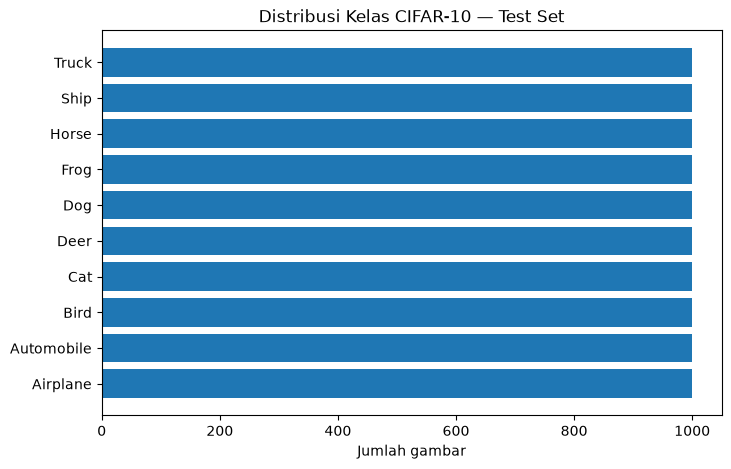

In [3]:
classes, counts = np.unique(
    y_test,
    return_counts=True
)

plt.figure(figsize=(8, 5))
plt.barh(
    classes_name,
    counts
)
plt.title(
    "Distribusi Kelas CIFAR-10 — Test Set"
)
plt.xlabel("Jumlah gambar")
plt.show()

## 2. Preprocessing

Harus identik dengan preprocessing training.

In [4]:
X_test = X_test.astype(
    "float32"
) / 255.0

y_cat_test = to_categorical(
    y_test,
    10
)

print("X_test:", X_test.shape)
print("y_cat_test:", y_cat_test.shape)

X_test: (10000, 32, 32, 3)
y_cat_test: (10000, 10)


## 3. Load Custom CNN dan SVM

In [5]:
CNN_MODEL_PATH = "models/cifar10_custom_cnn_v3.keras"
SVM_MODEL_PATH = "models/cifar10_svm_v3.joblib"

if not os.path.exists(CNN_MODEL_PATH):
    raise FileNotFoundError(
        f"{CNN_MODEL_PATH} tidak ditemukan. "
        "Jalankan notebook training terlebih dahulu."
    )

if not os.path.exists(SVM_MODEL_PATH):
    raise FileNotFoundError(
        f"{SVM_MODEL_PATH} tidak ditemukan. "
        "Jalankan notebook training terlebih dahulu."
    )

# Bersihkan session TensorFlow lama agar penggunaan VRAM lebih aman.
tf.keras.backend.clear_session()

# CNN hanya digunakan untuk inference / feature extraction.
cnn_model = load_model(
    CNN_MODEL_PATH,
    compile=False
)

# SVM Pipeline berisi StandardScaler + trained RBF-SVM.
svm_model = joblib.load(
    SVM_MODEL_PATH
)

print("CNN berhasil dimuat dari:")
print(CNN_MODEL_PATH)

print("\nSVM berhasil dimuat dari:")
print(SVM_MODEL_PATH)

print("\nCNN summary:")
cnn_model.summary()

print("\nSVM pipeline:")
print(svm_model)

I0000 00:00:1791402593.309208   69866 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 3672 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3050 6GB Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6


CNN berhasil dimuat dari:
models/cifar10_custom_cnn_v3.keras

SVM berhasil dimuat dari:
models/cifar10_svm_v3.joblib

CNN summary:


Model: "custom_cifar10_rgb_residual_v3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_image         │ (None, 32, 32, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 32, 32,    │      1,728 │ input_image[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 32, 32,    │        256 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_relu           │ (None, 32, 32,    │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_block1_conv1 │ (None, 32, 32,    │     36,864 │ stem_relu[0][0]   │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_block1_bn1   │ (None, 32, 32,    │        256 │ stage1_block1_co… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_block1_relu1 │ (None, 32, 32,    │          0 │ stage1_block1_bn… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_block1_conv2 │ (None, 32, 32,    │     36,864 │ stage1_block1_re… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_block1_bn2   │ (None, 32, 32,    │        256 │ stage1_block1_co… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_block1_add   │ (None, 32, 32,    │          0 │ stage1_block1_bn… │
│ (Add)               │ 64)               │            │ stem_relu[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_block1_out   │ (None, 32, 32,    │          0 │ stage1_block1_ad… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_block2_conv1 │ (None, 32, 32,    │     36,864 │ stage1_block1_ou… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_block2_bn1   │ (None, 32, 32,    │        256 │ stage1_block2_co… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_block2_relu1 │ (None, 32, 32,    │          0 │ stage1_block2_bn… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_block2_conv2 │ (None, 32, 32,    │     36,864 │ stage1_block2_re… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_block2_bn2   │ (None, 32, 32,    │        256 │ stage1_block2_co… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_block2_add   │ (None, 32, 32,    │          0 │ stage1_block2_bn

 Total params: 11,447,754 (43.67 MB)

 Trainable params: 11,437,130 (43.63 MB)

 Non-trainable params: 10,624 (41.50 KB)


SVM pipeline:
Pipeline(steps=[('scaler', StandardScaler()),
                ('svm', SVC(C=1, cache_size=2048, gamma=0.001))])


# 4. Feature Map Extraction pada Test Image

Sama seperti tahap feature-map extraction saat training, tetapi sekarang menggunakan gambar yang benar-benar unseen.

I0000 00:00:1791402594.835885   69939 service.cc:153] XLA service 0x7bfb6803e730 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1791402594.835906   69939 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 3050 6GB Laptop GPU, Compute Capability 8.6 (Driver: 13.2.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.26.0)
I0000 00:00:1791402594.845630   69939 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1791402595.002080   69939 cuda_dnn.cc:461] Loaded cuDNN version 92600
I0000 00:00:1791402599.059310   69939 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


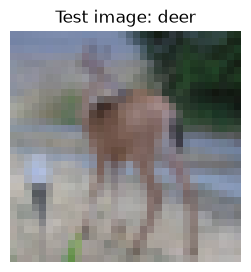

stem_relu: (1, 32, 32, 64)


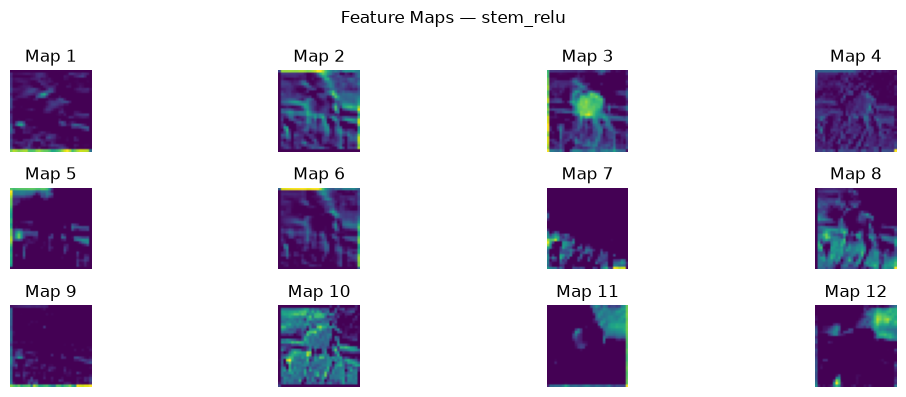

stage2_block2_out: (1, 16, 16, 128)


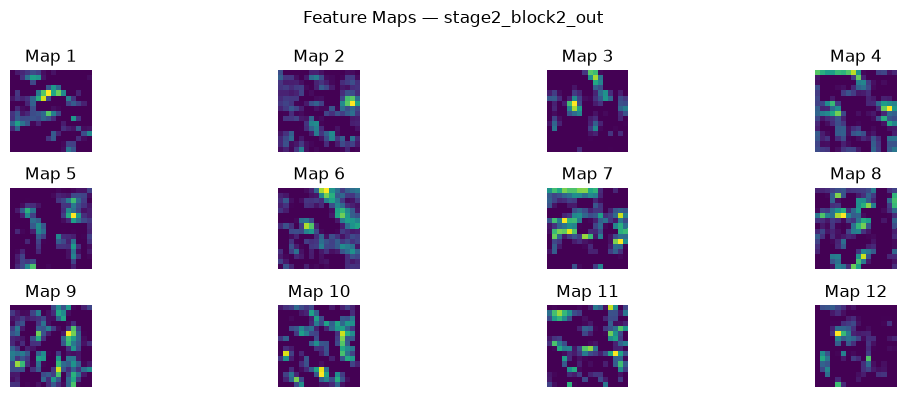

stage3_block2_out: (1, 8, 8, 256)


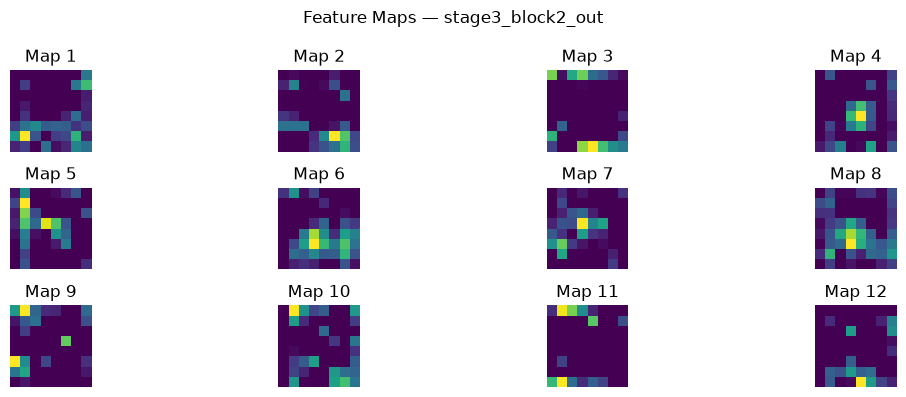

feature_map: (1, 4, 4, 512)


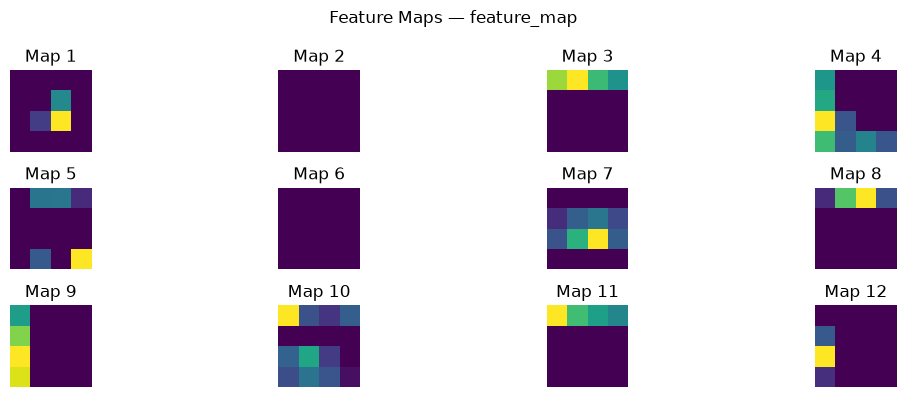

In [6]:
FEATURE_MAP_LAYERS = [
    "stem_relu",
    "stage2_block2_out",
    "stage3_block2_out",
    "feature_map"
]

feature_map_model = Model(
    inputs=cnn_model.input,
    outputs=[
        cnn_model.get_layer(name).output
        for name in FEATURE_MAP_LAYERS
    ],
    name="feature_map_extractor"
)

sample_index = 100
sample_image = X_test[
    sample_index:sample_index + 1
]

feature_maps = feature_map_model.predict(
    sample_image,
    verbose=0
)

plt.figure(figsize=(3, 3))
plt.imshow(sample_image[0])
plt.title(
    f"Test image: "
    f"{labels[y_test[sample_index]]}"
)
plt.axis("off")
plt.show()

for layer_name, fmap in zip(
    FEATURE_MAP_LAYERS,
    feature_maps
):
    n_show = min(
        12,
        fmap.shape[-1]
    )

    print(
        f"{layer_name}: {fmap.shape}"
    )

    plt.figure(figsize=(12, 4))

    for i in range(n_show):
        plt.subplot(
            3,
            4,
            i + 1
        )
        plt.imshow(
            fmap[0, :, :, i],
            cmap="viridis"
        )
        plt.title(
            f"Map {i + 1}"
        )
        plt.axis("off")

    plt.suptitle(
        f"Feature Maps — {layer_name}"
    )
    plt.tight_layout()
    plt.show()

## 5. Baseline: Evaluasi CNN Softmax

Ini hanya pembanding.

Hasil utama tugas tetap **CNN feature extraction + SVM**.

In [7]:
cnn_probability = cnn_model.predict(
    X_test,
    batch_size=128,
    verbose=1
)

cnn_prediction = np.argmax(
    cnn_probability,
    axis=1
)

cnn_accuracy = accuracy_score(
    y_test,
    cnn_prediction
)

print(
    f"CNN test accuracy: "
    f"{cnn_accuracy * 100:.2f}%"
)

79/79 ━━━━━━━━━━━━━━━━━━━━ 11s 74ms/step
CNN test accuracy: 93.03%


# 6. Extract CNN Features untuk Seluruh Test Set

SVM menerima output layer `svm_features`, yaitu proyeksi Dense + BatchNormalization tanpa ReLU setelah Global Average Pooling.

In [8]:
feature_extractor = Model(
    inputs=cnn_model.input,
    outputs=cnn_model.get_layer(
        "svm_features"
    ).output,
    name="cnn_feature_extractor"
)

X_test_features = feature_extractor.predict(
    X_test,
    batch_size=128,
    verbose=1
)

print(
    "Original test shape:",
    X_test.shape
)

print(
    "Extracted feature shape:",
    X_test_features.shape
)

79/79 ━━━━━━━━━━━━━━━━━━━━ 5s 45ms/step
Original test shape: (10000, 32, 32, 3)
Extracted feature shape: (10000, 512)


# 7. Klasifikasi SVM

In [9]:
svm_prediction = svm_model.predict(X_test_features)
svm_accuracy = accuracy_score(y_test, svm_prediction)
print("RGB CNN softmax test accuracy:", f"{cnn_accuracy:.4%}")
print("RGB CNN features + SVM test accuracy:", f"{svm_accuracy:.4%}")
print("Optional individual >95% milestone:", "PASS" if svm_accuracy > 0.95 else "NOT YET")

RGB CNN softmax test accuracy: 93.0300%
RGB CNN features + SVM test accuracy: 93.1300%
Optional individual >95% milestone: NOT YET


## 8. Classification Report SVM

In [10]:
print(
    classification_report(
        y_test,
        svm_prediction,
        target_names=labels,
        digits=4
    )
)

              precision    recall  f1-score   support

    airplane     0.9408    0.9370    0.9389      1000
  automobile     0.9617    0.9790    0.9703      1000
        bird     0.9198    0.9060    0.9128      1000
         cat     0.8665    0.8310    0.8484      1000
        deer     0.9190    0.9420    0.9304      1000
         dog     0.8850    0.8850    0.8850      1000
        frog     0.9357    0.9600    0.9477      1000
       horse     0.9616    0.9510    0.9563      1000
        ship     0.9620    0.9620    0.9620      1000
       truck     0.9581    0.9600    0.9590      1000

    accuracy                         0.9313     10000
   macro avg     0.9310    0.9313    0.9311     10000
weighted avg     0.9310    0.9313    0.9311     10000



## 9. Perbandingan CNN vs SVM

In [11]:
comparison = pd.DataFrame({
    "Classifier": [
        "CNN Softmax",
        "SVM on CNN Features"
    ],
    "Test Accuracy": [
        cnn_accuracy,
        svm_accuracy
    ]
})

display(comparison)

,Classifier,Test Accuracy
0,CNN Softmax,0.9303
1,SVM on CNN Features,0.9313


## 10. Confusion Matrix — SVM

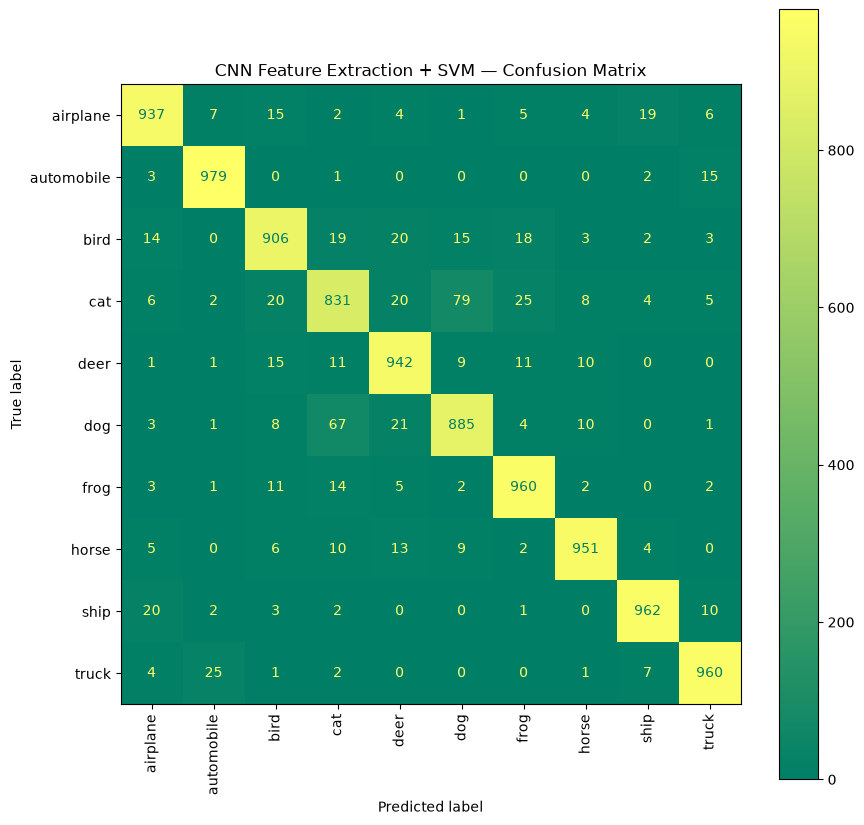

In [12]:
cm = confusion_matrix(
    y_test,
    svm_prediction
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=labels
)

fig, ax = plt.subplots(
    figsize=(10, 10)
)

disp.plot(
    ax=ax,
    xticks_rotation="vertical",
    cmap="summer"
)

plt.title(
    "CNN Feature Extraction + SVM "
    "— Confusion Matrix"
)

plt.show()

## 11. Beberapa Hasil Prediksi

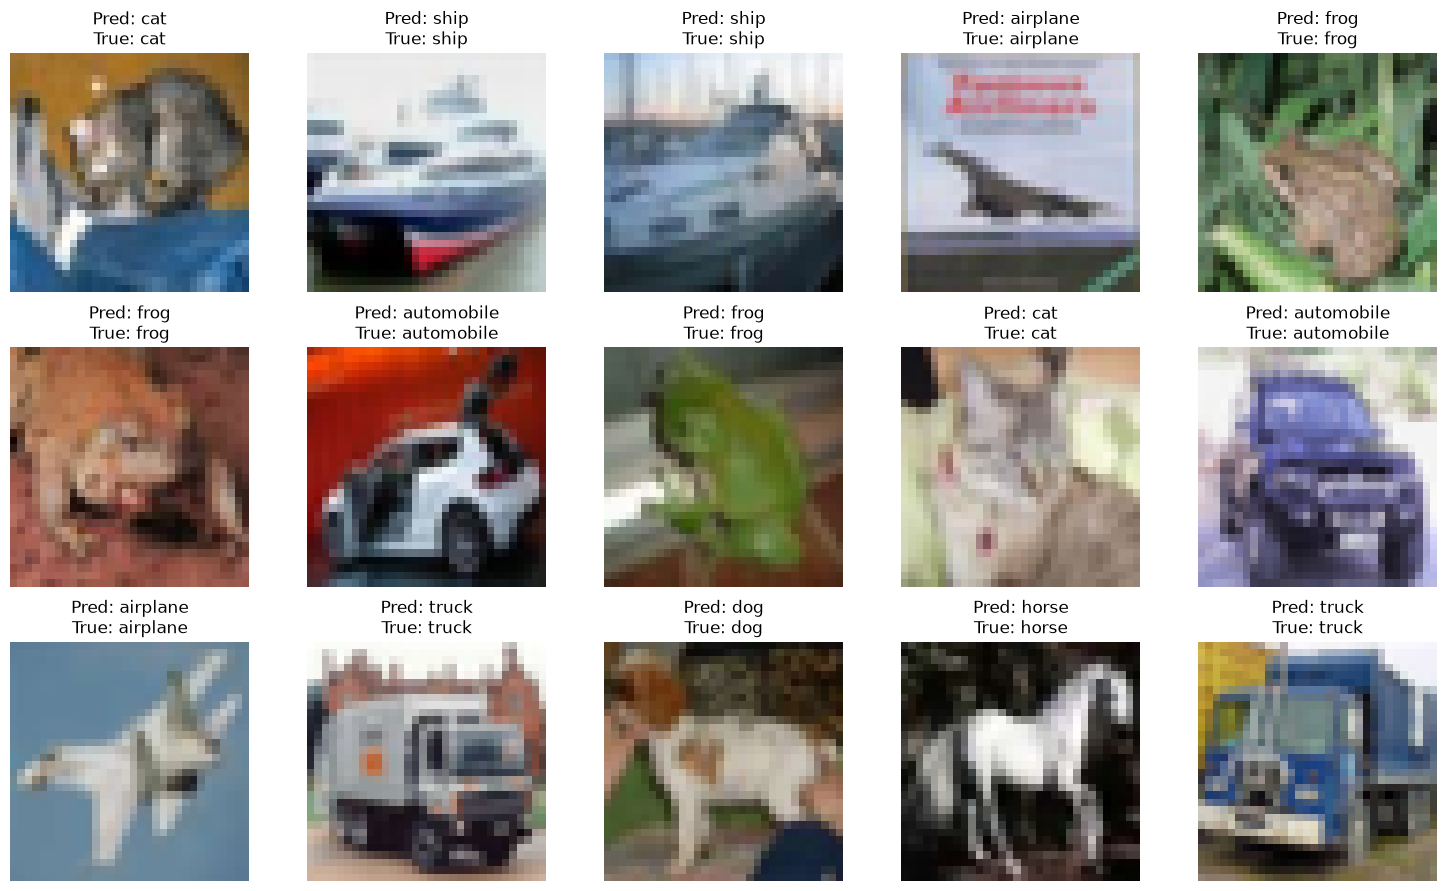

In [13]:
num_rows = 3
num_cols = 5
num_images = (
    num_rows * num_cols
)

plt.figure(figsize=(15, 9))

for i in range(num_images):
    plt.subplot(
        num_rows,
        num_cols,
        i + 1
    )

    plt.imshow(
        X_test[i]
    )

    predicted = int(
        svm_prediction[i]
    )

    actual = int(
        y_test[i]
    )

    plt.title(
        f"Pred: {labels[predicted]}\n"
        f"True: {labels[actual]}"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

# RGB v3 official test complete

The reported scores use saved RGB v3 CNN and SVM artifacts. No model fitting or parameter selection occurs in this notebook.
